<a href="https://colab.research.google.com/github/curpurpro/tugas-softmax-ml/blob/main/ai3%20no%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

5 Data Teratas:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Hasil Akhir Model (Data Normalisasi): f(x) = 0.19x + 0.12


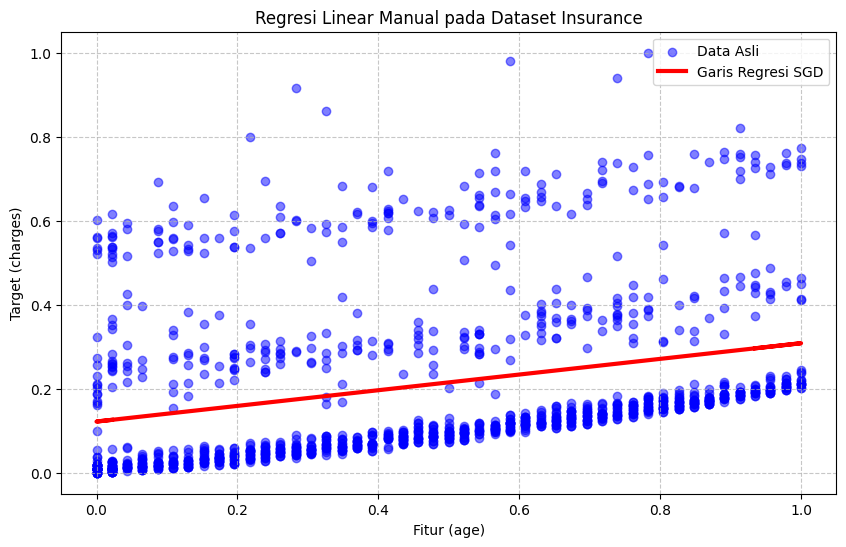

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- BAGIAN 1: MEMBACA DATA DARI FILE CSV ---
# Pastikan nama file sesuai dengan yang di sidebar kiri
nama_file = 'insurance dataset1.csv'
df = pd.read_csv(nama_file)

# Menampilkan 5 data teratas untuk memastikan file terbaca
print("5 Data Teratas:")
print(df.head())

# --- PENTING: SESUAIKAN NAMA KOLOM ---
# Di dataset insurance biasanya kolomnya adalah 'age' (X) dan 'charges' (y).
# Jika nama kolom di filemu berbeda (misal: 'BMI' atau 'X'), ganti tulisan di bawah ini:
nama_kolom_x = 'age'     # Ganti jika nama kolom X berbeda
nama_kolom_y = 'charges' # Ganti jika nama kolom Y berbeda

X = df[nama_kolom_x].values
y = df[nama_kolom_y].values

# Normalisasi sederhana agar angka tidak terlalu besar (Opsional tapi disarankan)
X_norm = (X - X.min()) / (X.max() - X.min())
y_norm = (y - y.min()) / (y.max() - y.min())

# --- BAGIAN 2: IMPLEMENTASI SGD ---
w = 0.0
b = 0.0
learning_rate = 0.01  # Gunakan LR yang lebih stabil
epochs = 1000

for epoch in range(epochs):
    for i in range(len(X_norm)):
        # Prediksi
        y_pred = w * X_norm[i] + b

        # Hitung Error
        error = y_norm[i] - y_pred

        # Update w dan b
        w = w + (2 * learning_rate * error * X_norm[i])
        b = b + (2 * learning_rate * error)

print(f"\nHasil Akhir Model (Data Normalisasi): f(x) = {w:.2f}x + {b:.2f}")

# --- BAGIAN 3: VISUALISASI ---
plt.figure(figsize=(10, 6))
plt.scatter(X_norm, y_norm, color='blue', alpha=0.5, label='Data Asli')
plt.plot(X_norm, w * X_norm + b, color='red', linewidth=3, label='Garis Regresi SGD')
plt.xlabel(f'Fitur ({nama_kolom_x})')
plt.ylabel(f'Target ({nama_kolom_y})')
plt.title('Regresi Linear Manual pada Dataset Insurance')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()